In [1]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

[np.float64(-800.9567744926558), np.float64(-810.6704660748622), np.float64(-904.7542258324486), np.float64(-904.7542258324486), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-931.1753186314819), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.float64(-932.4972276253604), np.floa

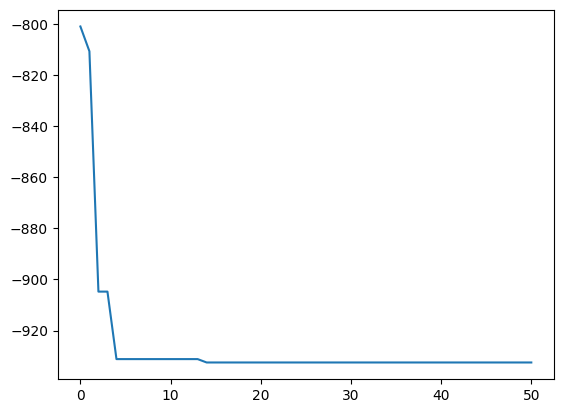

In [ ]:
from optimizer.aos import AOS
from optimizer.evaluator import evaluate
from utilities.filters import lma_filter, ema_filter, wma, sma_filter

prices = train_prices

def sma_fitness(candidate):
    short_n, long_n = candidate
    long = (wma(prices, long_n, sma_filter(long_n)))
    short = (wma(prices, short_n, sma_filter(short_n)))
    cash, buy_at, sell_at, equity_curve = evaluate(train_prices, short, long)
    return -cash #flip the sign for fitness since AOS is minimizing function

aos = AOS(100, 50, 5)
aos.run(sma_fitness, bounds = {
    "short_window": (2, 50),
    "long_window":  (51, 200)
})

print(aos.history["LE_energy"])
print(aos.history["LE_position"])

from matplotlib import pyplot as plt
plt.plot(aos.history["LE_energy"], label="energy curve")
plt.show()

In [3]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(P, label="prices") 
# ax.plot(temp_short, label = "short signal")
# ax.plot(temp_long, label = "long signal")

# for point in buy_at:
#   ax.plot(point[0], point[1], 'gx')

# for point in sell_at:
#   ax.plot(point[0], point[1], 'rx')

# # ax.plot(equity_curve, label = "portfolio value")
# ax.legend()
# plt.show()
